# VK Ads Auction Forecasting: защита решения

Цель ноутбука: показать полный путь решения от устройства задачи до финальной модели, объяснить генерацию признаков и наглядно сравнить ошибку разных подходов.

Основная идея решения: не заменять механику аукциона обычной ML-моделью, а сначала построить сильный replay-бейзлайн по прошлому месяцу, затем обучить ML-модель калибровать его ошибку.

## 1. Импорты и загрузка данных

In [268]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
DATA_RAW = ROOT / 'data' / 'raw'
DATA_FEATURES = ROOT / 'data' / 'features'
EXPERIMENTS = ROOT / 'artifacts' / 'experiments'
PREDICTIONS = ROOT / 'artifacts' / 'predictions'
sys.path.insert(0, str(ROOT))

from src.metrics import get_smoothed_mean_log_accuracy_ratio, get_smoothed_log_mape_column_value
from src.features import EPSILON, RANDOM_STATE, TARGET_COLUMNS, transform_target, inverse_transform_target

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')

In [269]:
users = pd.read_csv(DATA_RAW / 'users.tsv', sep='\t')
history = pd.read_csv(DATA_RAW / 'history.tsv', sep='\t')
validate = pd.read_csv(DATA_RAW / 'validate.tsv', sep='\t')
answers = pd.read_csv(DATA_RAW / 'validate_answers.tsv', sep='\t')[TARGET_COLUMNS]

data_overview = pd.DataFrame({
    'table': ['users', 'history', 'validate', 'validate_answers'],
    'rows': [len(users), len(history), len(validate), len(answers)],
    'columns': [users.shape[1], history.shape[1], validate.shape[1], answers.shape[1]],
})
data_overview

,table,rows,columns
0,users,27769,4
1,history,1147857,4
2,validate,1008,6
3,validate_answers,1008,3


## 2. Что нужно предсказывать

Для каждой рекламной кампании из `validate.tsv` нужно предсказать три доли аудитории:

- `at_least_one`: пользователь увидел объявление хотя бы 1 раз;
- `at_least_two`: хотя бы 2 раза;
- `at_least_three`: хотя бы 3 раза.

Важные правила задачи:

- если наша ставка `cpm` выше ставки конкурента, показ выигрывается с вероятностью `1.0`;
- если ставка равна максимальной ставке, вероятность выигрыша `0.5`;
- внутри одной пользовательской сессии одно и то же объявление повторно не показывается;
- новая сессия начинается после отсутствия показов в течение 6 часов.

Поэтому задача не является чисто табличной: в ней явно задана механика аукциона и сессий.

## 3. Первичный анализ данных

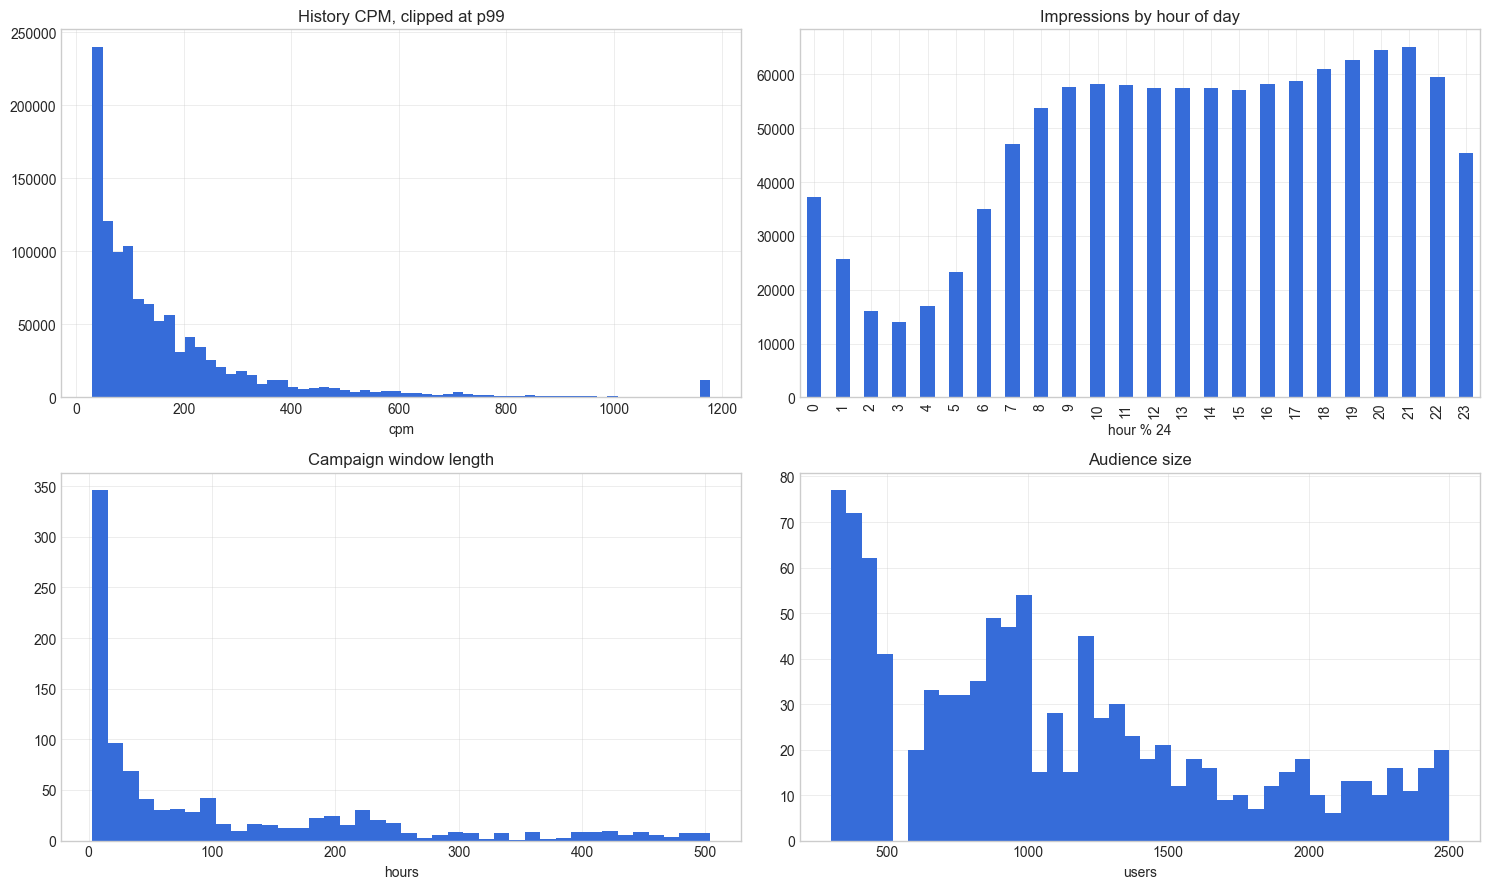

In [270]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

history['cpm'].clip(upper=history['cpm'].quantile(0.99)).hist(bins=60, ax=axes[0, 0])
axes[0, 0].set_title('History CPM, clipped at p99')
axes[0, 0].set_xlabel('cpm')

(history['hour'] % 24).value_counts().sort_index().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Impressions by hour of day')
axes[0, 1].set_xlabel('hour % 24')

(validate['hour_end'] - validate['hour_start'] + 1).hist(bins=40, ax=axes[1, 0])
axes[1, 0].set_title('Campaign window length')
axes[1, 0].set_xlabel('hours')

validate['audience_size'].hist(bins=40, ax=axes[1, 1])
axes[1, 1].set_title('Audience size')
axes[1, 1].set_xlabel('users')

plt.tight_layout()

In [271]:
pd.DataFrame({
    'history_hour_min': [history['hour'].min()],
    'history_hour_max': [history['hour'].max()],
    'validate_hour_start_min': [validate['hour_start'].min()],
    'validate_hour_start_max': [validate['hour_start'].max()],
    'history_users': [history['user_id'].nunique()],
    'all_users': [users['user_id'].nunique()],
    'publishers': [history['publisher'].nunique()],
})

,history_hour_min,history_hour_max,validate_hour_start_min,validate_hour_start_max,history_users,all_users,publishers
0,3,1490,747,1485,25536,27769,21


## 4. Общая схема предобработки и генерации признаков

Перед обучением модели сырые таблицы не используются напрямую. Сначала мы строим отдельную матрицу признаков `features_validate.tsv`: одна строка `validate.tsv` превращается в один вектор признаков кампании.

Общая схема пайплайна:

`users.tsv + history.tsv + validate.tsv` -> `src/features.py` / `prepare_features_for_tasks` -> `features_validate.tsv`

Затем отдельно считается симуляционный прогноз:

`history.tsv + validate.tsv` -> `src/replay.py --mode shift` -> `shift_replay_predictions.tsv`

На этапе ML эти два файла объединяются:

`features_validate.tsv + shift_replay_predictions.tsv` -> `features_full` -> residual-модель калибровки

Это важно подчеркнуть: модель обучается не на исходных строках `validate.tsv`, а на расширенном файле признаков, куда заранее добавлена вся созданная нами информация об аудитории, площадках, свежей истории и replay-прогнозе.

Группы признаков:

1. **Параметры кампании**: `cpm`, длина окна, размер аудитории, число площадок, час начала и окончания.
2. **Агрегаты аудитории**: средний возраст, пол, город, историческая активность пользователей, средние ставки в их истории.
3. **Агрегаты площадок**: объем показов, число пользователей, квантили `cpm`, активность по часам.
4. **Свежая история за 31 день**: активность выбранной аудитории и выбранных площадок перед стартом кампании.
5. **Пересечение аудитории и площадок**: сколько показов было именно у пользователей кампании именно на выбранных площадках.
6. **Shift replay**: прогноз, полученный симуляцией кампании на таком же временном окне предыдущего месяца.

In [272]:
features = pd.read_csv(DATA_FEATURES / 'features_validate.tsv', sep='\t')
shift_replay = pd.read_csv(PREDICTIONS / 'shift_replay_predictions.tsv', sep='\t').rename(columns={
    'at_least_one': 'shift_replay_at_least_one',
    'at_least_two': 'shift_replay_at_least_two',
    'at_least_three': 'shift_replay_at_least_three',
})
features_full = pd.concat([features, shift_replay], axis=1)

def feature_group(name: str) -> str:
    if name.startswith('shift_replay'):
        return 'shift_replay'
    if name.startswith('recent_31d_intersection'):
        return 'recent_intersection'
    if name.startswith('recent_31d_audience'):
        return 'recent_audience'
    if name.startswith('recent_31d_publishers'):
        return 'recent_publishers'
    if name.startswith('audience_'):
        return 'audience_aggregates'
    if name.startswith('publisher_'):
        return 'publisher_aggregates'
    if name.startswith('cpm') or name == 'log_cpm':
        return 'cpm'
    if 'hour' in name or 'window' in name:
        return 'time_window'
    return 'campaign'

feature_catalog = pd.DataFrame({
    'feature': features_full.columns,
    'group': [feature_group(c) for c in features_full.columns],
    'missing': features_full.isna().sum().to_numpy(),
    'nunique': features_full.nunique(dropna=False).to_numpy(),
})

feature_group_counts = feature_catalog.groupby('group').size().sort_values(ascending=False).rename('feature_count')
feature_group_counts

group
audience_aggregates     34
publisher_aggregates    28
recent_audience          8
recent_intersection      8
recent_publishers        8
time_window              6
cpm                      4
shift_replay             3
campaign                 1
Name: feature_count, dtype: int64

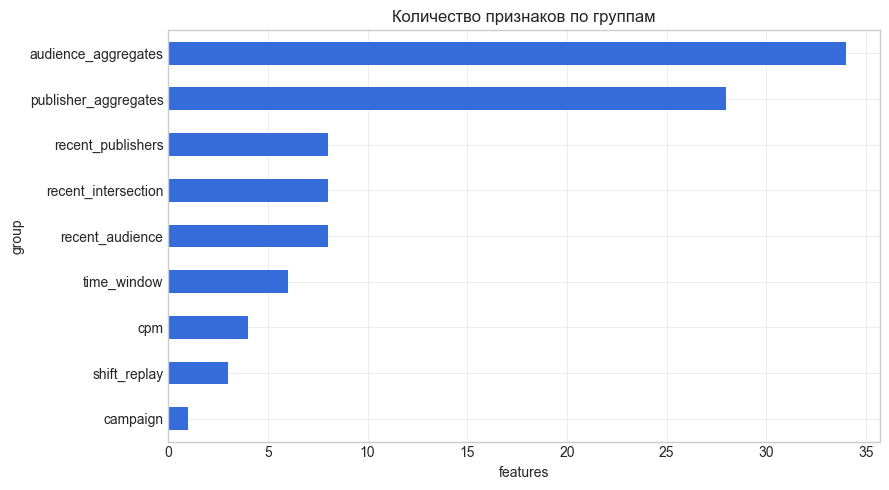

In [273]:
feature_group_counts.sort_values().plot(kind='barh', figsize=(9, 5))
plt.title('Количество признаков по группам')
plt.xlabel('features')
plt.tight_layout()

### 4.1. Что именно происходит при предобработке

Ниже таблица с логикой генерации признаков. Она нужна для защиты: по ней видно, что большая часть работы была сделана до обучения модели, а ML получает уже осмысленную кампанийную матрицу.

In [274]:
preprocessing_steps = pd.DataFrame([
    {
        'stage': 'campaign parameters',
        'source': 'validate.tsv',
        'generated_features': 'cpm, log_cpm, window_length, hour_of_day, publisher_count, audience_size',
        'why_important': 'задают цену, длительность и масштаб кампании; напрямую влияют на шанс выиграть аукцион и набрать показы',
        'used_in_model': 'features_validate.tsv',
    },
    {
        'stage': 'audience aggregation',
        'source': 'users.tsv + history.tsv + user_ids from validate.tsv',
        'generated_features': 'средний возраст/пол/город, user_impressions, active_hours, publishers, user_cpm_*',
        'why_important': 'одинаковая кампания по-разному работает на активной и неактивной аудитории; история пользователей показывает вероятность будущих контактов',
        'used_in_model': 'features_validate.tsv',
    },
    {
        'stage': 'publisher aggregation',
        'source': 'history.tsv + publishers from validate.tsv',
        'generated_features': 'pub_impressions, pub_users, pub_cpm_mean/median/p75/p90/p95, pub_hour_*',
        'why_important': 'площадки отличаются объемом трафика и уровнем конкуренции по cpm; квантили ставок помогают понять силу нашей ставки',
        'used_in_model': 'features_validate.tsv',
    },
    {
        'stage': 'recent activity window',
        'source': 'history.tsv before campaign start',
        'generated_features': 'recent_31d_audience_*, recent_31d_publishers_*',
        'why_important': 'тестовый месяц находится в будущем, поэтому недавняя активность ближе к прогнозируемому периоду, чем вся история целиком',
        'used_in_model': 'features_validate.tsv',
    },
    {
        'stage': 'audience-publisher intersection',
        'source': 'history.tsv filtered by campaign users and publishers',
        'generated_features': 'recent_31d_intersection_impressions/sessions/win_rate/active_user_share',
        'why_important': 'самый близкий табличный аналог будущих показов: именно эти пользователи на именно этих площадках',
        'used_in_model': 'features_validate.tsv',
    },
    {
        'stage': 'shift replay simulation',
        'source': 'history.tsv + validate.tsv shifted by 31 days',
        'generated_features': 'shift_replay_at_least_one/two/three',
        'why_important': 'использует правила аукциона и сессий напрямую, поэтому является сильным базовым прогнозом',
        'used_in_model': 'joined with features_validate.tsv before residual calibration',
    },
])
preprocessing_steps

,stage,source,generated_features,why_important,used_in_model
0,campaign parameters,validate.tsv,"cpm, log_cpm, window_length, hour_of_day, publ...","задают цену, длительность и масштаб кампании; ...",features_validate.tsv
1,audience aggregation,users.tsv + history.tsv + user_ids from valida...,"средний возраст/пол/город, user_impressions, a...",одинаковая кампания по-разному работает на акт...,features_validate.tsv
2,publisher aggregation,history.tsv + publishers from validate.tsv,"pub_impressions, pub_users, pub_cpm_mean/media...",площадки отличаются объемом трафика и уровнем ...,features_validate.tsv
3,recent activity window,history.tsv before campaign start,"recent_31d_audience_*, recent_31d_publishers_*","тестовый месяц находится в будущем, поэтому не...",features_validate.tsv
4,audience-publisher intersection,history.tsv filtered by campaign users and pub...,recent_31d_intersection_impressions/sessions/w...,самый близкий табличный аналог будущих показов...,features_validate.tsv
5,shift replay simulation,history.tsv + validate.tsv shifted by 31 days,shift_replay_at_least_one/two/three,"использует правила аукциона и сессий напрямую,...",joined with features_validate.tsv before resid...


### 4.2. Как признаки попадают в модель

`features_validate.tsv` содержит все табличные признаки, созданные на этапе предобработки. Затем к нему добавляются три replay-колонки из `shift_replay_predictions.tsv`. Полученная матрица `features_full` используется как вход `X` для residual-модели.

In [275]:
model_input_summary = pd.DataFrame([
    {'object': 'features_validate.tsv', 'rows': len(features), 'columns': features.shape[1], 'role': 'созданные табличные признаки кампаний'},
    {'object': 'shift_replay_predictions.tsv', 'rows': len(shift_replay), 'columns': shift_replay.shape[1], 'role': 'симуляционный baseline как признаки'},
    {'object': 'features_full', 'rows': len(features_full), 'columns': features_full.shape[1], 'role': 'финальный вход X для ML-калибровки'},
    {'object': 'validate_answers.tsv', 'rows': len(answers), 'columns': answers.shape[1], 'role': 'целевая переменная y'},
])
model_input_summary

,object,rows,columns,role
0,features_validate.tsv,1008,97,созданные табличные признаки кампаний
1,shift_replay_predictions.tsv,1008,3,симуляционный baseline как признаки
2,features_full,1008,100,финальный вход X для ML-калибровки
3,validate_answers.tsv,1008,3,целевая переменная y


## 5. Почему replay-бейзлайн сильный

`shift_replay` берет кампанию из validate, сдвигает ее окно на 31 день назад и проигрывает ее на исторических показах:

- фильтрует события по пользователям аудитории;
- фильтрует события по выбранным площадкам;
- сравнивает `cpm` кампании с историческим `cpm` конкурента;
- внутри сессий считает вероятность хотя бы одного выигрыша;
- агрегирует вероятности до `at_least_one/two/three`.

Это не обучаемая модель, а симуляция правил задачи на прошлом месяце. Поэтому она является более сильной отправной точкой, чем обычный табличный ML.

## 6. ML как калибровка replay

Обычная ML-модель на 1008 строках легко переобучается. Поэтому финальная схема не предсказывает таргет с нуля, а учит поправку к replay-прогнозу.

Формула:

`residual = log(answer + eps) - log(shift_replay + eps)`

`prediction = exp(log(shift_replay + eps) + shrink * residual_model(features_full)) - eps`

`features_full` здесь означает `features_validate.tsv + shift_replay_predictions.tsv`. `shrink` ограничивает силу ML-поправки. Это важно, потому что полная поправка может переисправлять хороший replay-бейзлайн.

In [276]:
def read_prediction(filename: str) -> pd.DataFrame:
    file_path = PREDICTIONS / filename
    if not file_path.exists():
        raise FileNotFoundError(f"Prediction file not found: {file_path}")
    return pd.read_csv(file_path, sep='\t')[TARGET_COLUMNS]

# В защитном ноутбуке сравниваем только основной pipeline.
# Экспериментальные ML baseline / CatBoost вынесены в experiments/ и feature_selection.ipynb.
prediction_sources = [
    ('shift_replay', 'shift_replay_predictions.tsv', 'simulation baseline'),
    ('replay_calibrated', 'replay_calibrated_predictions.tsv', 'residual calibration'),
]

rows = []
for name, filename, kind in prediction_sources:
    pred = read_prediction(filename)
    rows.append({
        'approach': name,
        'file': filename,
        'kind': kind,
        'metric': get_smoothed_mean_log_accuracy_ratio(answers, pred),
    })

metric_table = pd.DataFrame(rows).sort_values('metric').reset_index(drop=True)
baseline_metric = metric_table.loc[metric_table['approach'] == 'shift_replay', 'metric'].iloc[0]
metric_table['delta_vs_shift_replay'] = metric_table['metric'] - baseline_metric
metric_table['relative_change_%'] = 100 * metric_table['delta_vs_shift_replay'] / baseline_metric
metric_table


,approach,file,kind,metric,delta_vs_shift_replay,relative_change_%
0,replay_calibrated,replay_calibrated_predictions.tsv,residual calibration,11.18,-0.3,-2.61324
1,shift_replay,shift_replay_predictions.tsv,simulation baseline,11.48,0.0,0.00000


### 6.1 Честные метрики для графика

Для графика нельзя смешивать full-train saved metric и честную валидацию. Ниже отдельно считаются:

- `shift_replay`: симуляция кампании в окне, сдвинутом на 31 день назад;
- `replay_calibrated`: сохраненный OOF-прогноз residual-калибровки;
- `catboost_time_split` и `hgb_time_split`: модели, обученные только на первых 80% кампаний по времени и проверенные на последних 20%;
- `*_saved_full_train`: справочные значения, их не используем как честное сравнение, потому что модель обучалась на всех строках validate.


In [277]:
def time_split_indices(tasks: pd.DataFrame, valid_fraction: float = 0.2):
    ordered_indices = tasks.sort_values('hour_start').index.to_numpy()
    valid_size = max(1, int(round(len(ordered_indices) * valid_fraction)))
    return ordered_indices[:-valid_size], ordered_indices[-valid_size:]

train_index, valid_index = time_split_indices(validate, valid_fraction=0.2)
valid_answers = answers.loc[valid_index].reset_index(drop=True)


def metric_for_frame(pred: pd.DataFrame, index=None) -> float:
    if index is None:
        return get_smoothed_mean_log_accuracy_ratio(answers, pred[TARGET_COLUMNS])
    return get_smoothed_mean_log_accuracy_ratio(
        answers.loc[index].reset_index(drop=True),
        pred.loc[index, TARGET_COLUMNS].reset_index(drop=True),
    )


def evaluate_time_split_model(name: str, model, feature_frame: pd.DataFrame) -> dict[str, object]:
    estimator = MultiOutputRegressor(model)
    estimator.fit(feature_frame.iloc[train_index], transform_target(answers.iloc[train_index]))
    valid_pred = pd.DataFrame(
        inverse_transform_target(estimator.predict(feature_frame.iloc[valid_index])),
        columns=TARGET_COLUMNS,
    )
    return {
        'approach': name,
        'metric': get_smoothed_mean_log_accuracy_ratio(valid_answers, valid_pred),
        'validation': 'time split: train first 80%, validate last 20%',
        'use_on_chart': True,
    }


def fit_replay_calibration_time_split() -> tuple[float, float, pd.DataFrame]:
    base_prediction = shift_replay_pred.rename(columns={
        'shift_replay_at_least_one': 'at_least_one',
        'shift_replay_at_least_two': 'at_least_two',
        'shift_replay_at_least_three': 'at_least_three',
    })[TARGET_COLUMNS]

    base_log = transform_target(base_prediction)
    answer_log = transform_target(answers)
    residual_target = answer_log - base_log

    calibration_model = MultiOutputRegressor(make_pipeline(StandardScaler(), Ridge(alpha=50.0)))
    calibration_model.fit(features_full.iloc[train_index], residual_target[train_index])
    residual_valid = calibration_model.predict(features_full.iloc[valid_index])
    base_log_valid = base_log[valid_index]

    shrink_values = np.round(np.arange(0.0, 1.01, 0.05), 2)
    rows = []
    for shrink in shrink_values:
        calibrated = np.clip(np.exp(base_log_valid + shrink * residual_valid) - EPSILON, 0.0, 1.0)
        pred = pd.DataFrame(calibrated, columns=TARGET_COLUMNS)
        rows.append({
            'shrink': shrink,
            'metric': get_smoothed_mean_log_accuracy_ratio(valid_answers, pred),
        })
    shrink_table = pd.DataFrame(rows)
    best = shrink_table.loc[shrink_table['metric'].idxmin()]
    return float(best['metric']), float(best['shrink']), shrink_table

shift_replay_pred = read_prediction('shift_replay_predictions.tsv')
replay_calibrated_pred = read_prediction('replay_calibrated_predictions.tsv')
ml_time_saved_pred = read_prediction('ml_time_predictions.tsv') if (PREDICTIONS / 'ml_time_predictions.tsv').exists() else None
catboost_optuna_saved_pred = read_prediction('catboost_optuna_predictions.tsv') if (PREDICTIONS / 'catboost_optuna_predictions.tsv').exists() else None

zero_pred = pd.DataFrame(0.0, index=answers.index, columns=TARGET_COLUMNS)
replay_calibrated_time_metric, replay_calibrated_best_shrink, shrink_metric_table = fit_replay_calibration_time_split()
best_shrink_row = shrink_metric_table.loc[shrink_metric_table['metric'].idxmin()]

honest_rows = [
    {
        'approach': 'zero_baseline',
        'metric': metric_for_frame(zero_pred, valid_index),
        'validation': 'time split: validate last 20%; predicts zeros for every target',
        'use_on_chart': True,
    },
    {
        'approach': 'shift_replay',
        'metric': metric_for_frame(shift_replay_pred, valid_index),
        'validation': 'time split: validate last 20%; shifted by 31 days',
        'use_on_chart': True,
    },
    {
        'approach': 'replay_calibrated_time_split',
        'metric': replay_calibrated_time_metric,
        'validation': f'time split residual calibration; best shrink={replay_calibrated_best_shrink:.2f}',
        'use_on_chart': True,
    },
    evaluate_time_split_model(
        'ridge_time_split',
        make_pipeline(StandardScaler(), Ridge(alpha=5.0)),
        features,
    ),
    evaluate_time_split_model(
        'random_forest_time_split',
        RandomForestRegressor(
            n_estimators=300,
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        features,
    ),
    evaluate_time_split_model(
        'extra_trees_time_split',
        ExtraTreesRegressor(
            n_estimators=400,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        features,
    ),
    evaluate_time_split_model(
        'gradient_boosting_time_split',
        GradientBoostingRegressor(
            n_estimators=250,
            learning_rate=0.03,
            max_depth=3,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
        ),
        features,
    ),
    evaluate_time_split_model(
        'catboost_time_split',
        CatBoostRegressor(
            iterations=500,
            learning_rate=0.03,
            depth=5,
            l2_leaf_reg=5.0,
            loss_function='RMSE',
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
        ),
        features,
    ),
    evaluate_time_split_model(
        'catboost_optuna_time_split',
        CatBoostRegressor(
            iterations=938,
            learning_rate=0.028129502019980532,
            depth=5,
            l2_leaf_reg=1.4019006821289495,
            random_strength=0.018787593472294112,
            bagging_temperature=0.021522742443020878,
            min_data_in_leaf=13,
            loss_function='RMSE',
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
        ),
        features,
    ),
    evaluate_time_split_model(
        'hist_gradient_boosting_time_split',
        HistGradientBoostingRegressor(
            max_iter=250,
            learning_rate=0.03,
            max_leaf_nodes=15,
            l2_regularization=0.05,
            random_state=RANDOM_STATE,
        ),
        features,
    ),
]

honest_rows.append({
    'approach': 'replay_calibrated_oof_saved',
    'metric': metric_for_frame(replay_calibrated_pred),
    'validation': 'not same protocol: saved OOF/k-fold predictions over all rows',
    'use_on_chart': False,
})

if ml_time_saved_pred is not None:
    honest_rows.append({
        'approach': 'ml_time_saved_full_train',
        'metric': metric_for_frame(ml_time_saved_pred),
        'validation': 'not honest: saved predictions after fitting on all validate rows',
        'use_on_chart': False,
    })

if catboost_optuna_saved_pred is not None:
    honest_rows.append({
        'approach': 'catboost_optuna_saved_full_train',
        'metric': metric_for_frame(catboost_optuna_saved_pred),
        'validation': 'not honest: saved predictions after fitting on all validate rows',
        'use_on_chart': False,
    })

honest_metric_table = (
    pd.DataFrame(honest_rows)
    .sort_values(['use_on_chart', 'metric'], ascending=[False, True])
    .reset_index(drop=True)
)
honest_metric_table['metric'] = honest_metric_table['metric'].round(2)
honest_metric_table

,approach,metric,validation,use_on_chart
0,replay_calibrated_time_split,11.64,time split residual calibration; best shrink=0.40,True
1,shift_replay,11.80,time split: validate last 20%; shifted by 31 days,True
2,catboost_optuna_time_split,14.17,"time split: train first 80%, validate last 20%",True
3,catboost_time_split,16.87,"time split: train first 80%, validate last 20%",True
4,hist_gradient_boosting_time_split,16.98,"time split: train first 80%, validate last 20%",True
5,gradient_boosting_time_split,19.72,"time split: train first 80%, validate last 20%",True
6,extra_trees_time_split,22.15,"time split: train first 80%, validate last 20%",True
7,random_forest_time_split,25.09,"time split: train first 80%, validate last 20%",True
8,ridge_time_split,36.12,"time split: train first 80%, validate last 20%",True
9,zero_baseline,203.65,time split: validate last 20%; predicts zeros ...,True


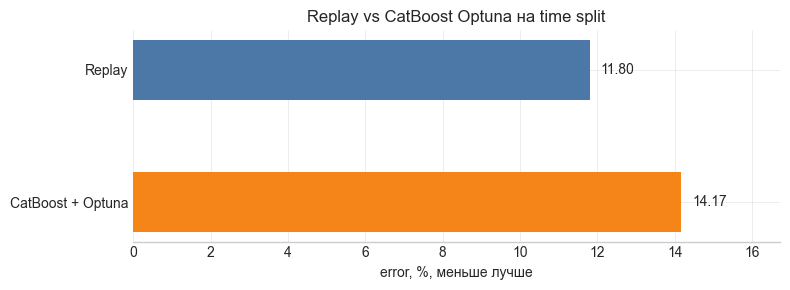

In [278]:
comparison_chart = honest_metric_table[
    honest_metric_table['approach'].isin([
        'shift_replay',
        'catboost_optuna_time_split',
    ])
].sort_values('metric', ascending=False)

labels = {
    'shift_replay': 'Replay',
    'catboost_optuna_time_split': 'CatBoost + Optuna',
}
colors = {
    'shift_replay': '#4C78A8',
    'catboost_optuna_time_split': '#F58518',
}

fig, ax = plt.subplots(figsize=(8, 3))
y_labels = [labels[name] for name in comparison_chart['approach']]
ax.barh(
    y_labels,
    comparison_chart['metric'],
    color=[colors[name] for name in comparison_chart['approach']],
    height=0.45,
)
ax.set_title('Replay vs CatBoost Optuna на time split')
ax.set_xlabel('error, %, меньше лучше')
ax.set_xlim(0, comparison_chart['metric'].max() * 1.18)

for i, value in enumerate(comparison_chart['metric']):
    ax.text(value + comparison_chart['metric'].max() * 0.02, i, f'{value:.2f}', va='center')

ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()

### 6.1.2 Optuna для CatBoost

Для обычной ML-модели replay-признаки не использовались. Поэтому Optuna применялась к CatBoost на чистом ML-наборе `features_validate.tsv`: это лучший набор без `shift_replay_*`, соответствующий эксперименту `without_replay`. Тюнинг улучшил CatBoost с `16.87` до `14.17`, но replay остался сильнее.


#### Важность гиперпараметров Optuna

Важность рассчитана методом fANOVA по trials Optuna. Чем больше значение, тем сильнее параметр объясняет различия метрики между запусками.

,hyperparameter,importance,importance_%
0,depth,0.401,40.1
1,iterations,0.265,26.5
2,min_data_in_leaf,0.118,11.8
3,learning_rate,0.104,10.4
4,l2_leaf_reg,0.061,6.1
5,bagging_temperature,0.037,3.7
6,random_strength,0.014,1.4


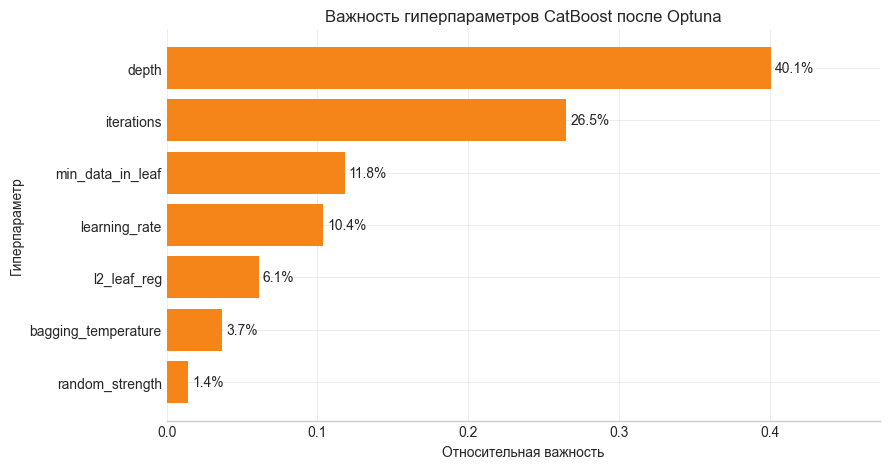

In [279]:
optuna_importance = pd.read_csv(
    EXPERIMENTS / 'optuna_hyperparameter_importance.tsv',
    sep='\t',
).sort_values('importance', ascending=False)
optuna_importance['importance_%'] = (100 * optuna_importance['importance']).round(1)

display(optuna_importance)

plot_data = optuna_importance.sort_values('importance')
fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(plot_data['hyperparameter'], plot_data['importance'], color='#F58518')
ax.bar_label(bars, labels=[f'{value:.1f}%' for value in plot_data['importance_%']], padding=3)
ax.set_title('Важность гиперпараметров CatBoost после Optuna')
ax.set_xlabel('Относительная важность')
ax.set_ylabel('Гиперпараметр')
ax.set_xlim(0, plot_data['importance'].max() * 1.18)
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()

### 6.1.1 Полное сравнение подходов

На этом графике отдельно показаны нулевой baseline, replay-подходы и обычные ML-модели на одном time split.


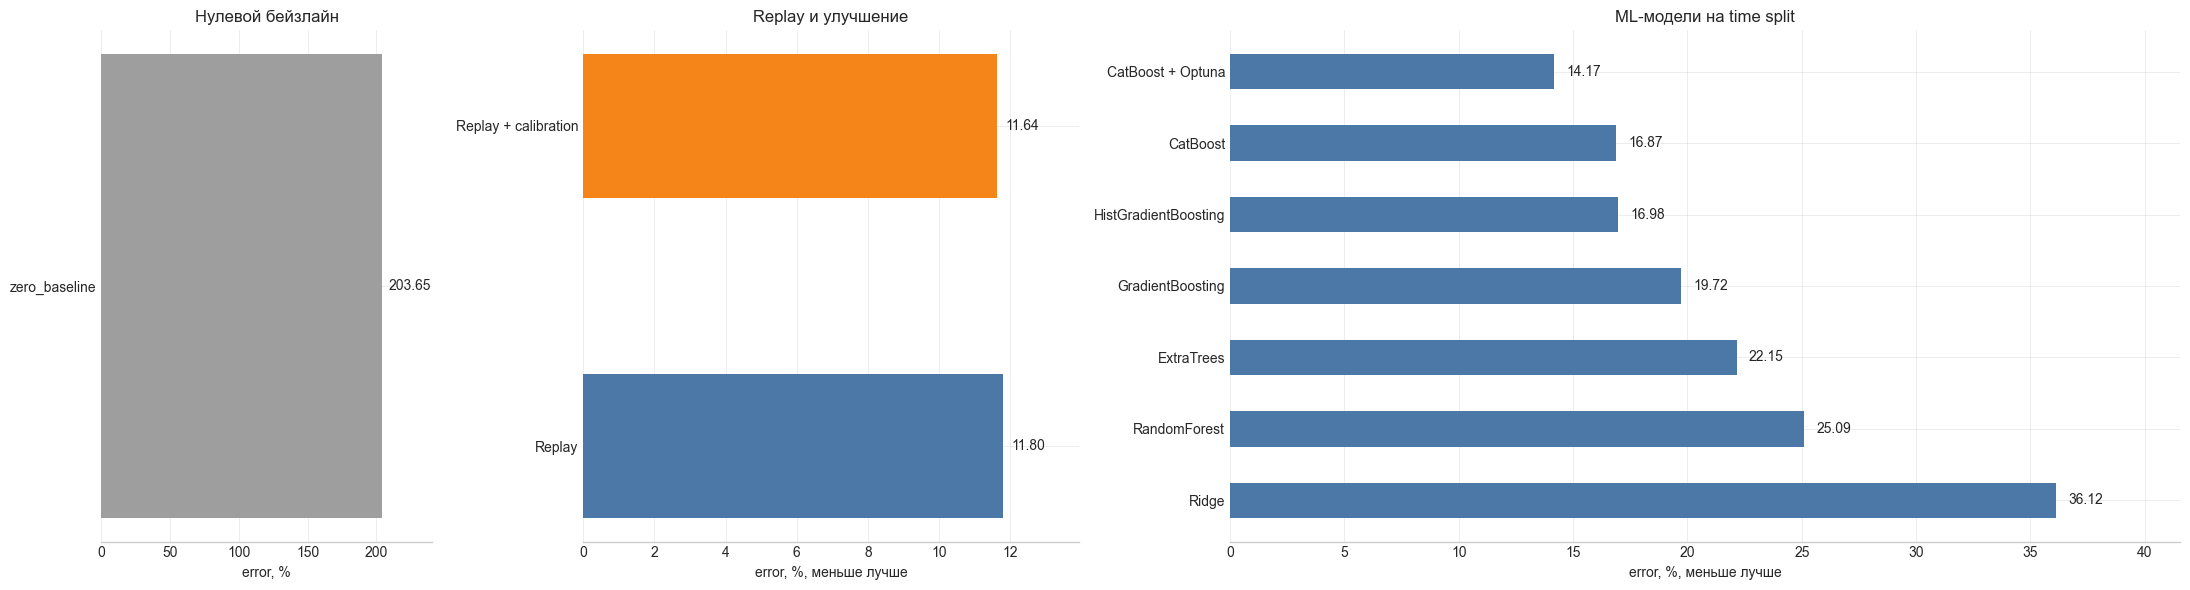

In [280]:
zero_chart = honest_metric_table[
    honest_metric_table['approach'].isin(['zero_baseline'])
].sort_values('metric', ascending=False)

replay_chart = honest_metric_table[
    honest_metric_table['approach'].isin([
        'shift_replay',
        'replay_calibrated_time_split',
    ])
].sort_values('metric', ascending=False)

ml_chart = honest_metric_table[
    honest_metric_table['approach'].isin([
        'ridge_time_split',
        'random_forest_time_split',
        'extra_trees_time_split',
        'gradient_boosting_time_split',
        'hist_gradient_boosting_time_split',
        'catboost_time_split',
        'catboost_optuna_time_split',
    ])
].sort_values('metric', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(22, 6), gridspec_kw={'width_ratios': [0.8, 1.2, 2.3]})

axes[0].barh(zero_chart['approach'], zero_chart['metric'], color='#9E9E9E', height=0.35)
axes[0].set_title('Нулевой бейзлайн')
axes[0].set_xlabel('error, %')
axes[0].set_xlim(0, zero_chart['metric'].max() * 1.18)
for i, value in enumerate(zero_chart['metric']):
    axes[0].text(value + zero_chart['metric'].max() * 0.025, i, f'{value:.2f}', va='center')
axes[0].spines[['top', 'right', 'left']].set_visible(False)

replay_labels = {
    'shift_replay': 'Replay',
    'replay_calibrated_time_split': 'Replay + calibration',
}
replay_colors = {
    'shift_replay': '#4C78A8',
    'replay_calibrated_time_split': '#F58518',
}
axes[1].barh(
    [replay_labels[name] for name in replay_chart['approach']],
    replay_chart['metric'],
    color=[replay_colors[name] for name in replay_chart['approach']],
    height=0.45,
)
axes[1].set_title('Replay и улучшение')
axes[1].set_xlabel('error, %, меньше лучше')
axes[1].set_xlim(0, replay_chart['metric'].max() * 1.18)
for i, value in enumerate(replay_chart['metric']):
    axes[1].text(value + replay_chart['metric'].max() * 0.02, i, f'{value:.2f}', va='center')
axes[1].spines[['top', 'right', 'left']].set_visible(False)

ml_labels = {
    'ridge_time_split': 'Ridge',
    'random_forest_time_split': 'RandomForest',
    'extra_trees_time_split': 'ExtraTrees',
    'gradient_boosting_time_split': 'GradientBoosting',
    'hist_gradient_boosting_time_split': 'HistGradientBoosting',
    'catboost_time_split': 'CatBoost',
    'catboost_optuna_time_split': 'CatBoost + Optuna',
}
axes[2].barh(
    [ml_labels[name] for name in ml_chart['approach']],
    ml_chart['metric'],
    color='#4C78A8',
    height=0.5,
)
axes[2].set_title('ML-модели на time split')
axes[2].set_xlabel('error, %, меньше лучше')
axes[2].set_xlim(0, ml_chart['metric'].max() * 1.15)
for i, value in enumerate(ml_chart['metric']):
    axes[2].text(value + ml_chart['metric'].max() * 0.015, i, f'{value:.2f}', va='center')
axes[2].spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()

### 6.2 Калибровка replay

Replay уже дает сильный прогноз, поэтому калибровка не предсказывает охват с нуля. Модель учит логарифмическую ошибку replay и добавляет к нему ограниченную `shrink`-поправку. Так мы исправляем систематические ошибки replay, но не даем ML-модели сильно переобучиться.


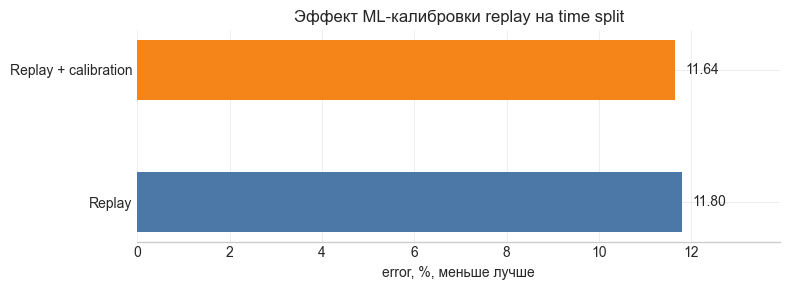

In [281]:
calibration_chart = honest_metric_table[
    honest_metric_table['approach'].isin([
        'shift_replay',
        'replay_calibrated_time_split',
    ])
].sort_values('metric', ascending=False)

labels = {
    'shift_replay': 'Replay',
    'replay_calibrated_time_split': 'Replay + calibration',
}
colors = {
    'shift_replay': '#4C78A8',
    'replay_calibrated_time_split': '#F58518',
}

fig, ax = plt.subplots(figsize=(8, 3))
y_labels = [labels[name] for name in calibration_chart['approach']]
ax.barh(
    y_labels,
    calibration_chart['metric'],
    color=[colors[name] for name in calibration_chart['approach']],
    height=0.45,
)
ax.set_title('Эффект ML-калибровки replay на time split')
ax.set_xlabel('error, %, меньше лучше')
ax.set_xlim(0, calibration_chart['metric'].max() * 1.18)

for i, value in enumerate(calibration_chart['metric']):
    ax.text(value + calibration_chart['metric'].max() * 0.02, i, f'{value:.2f}', va='center')

ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()

### 6.2 Влияние shrink на replay-калибровку

`shrink` контролирует силу ML-поправки к replay. При `shrink = 0` остается чистый replay, при `shrink = 1` используется полная поправка residual-модели.


,shrink,metric
0,0.00,11.80
1,0.05,11.77
2,0.10,11.75
3,0.15,11.72
4,0.20,11.70
5,0.25,11.68
6,0.30,11.66
7,0.35,11.65
8,0.40,11.64
9,0.45,11.64


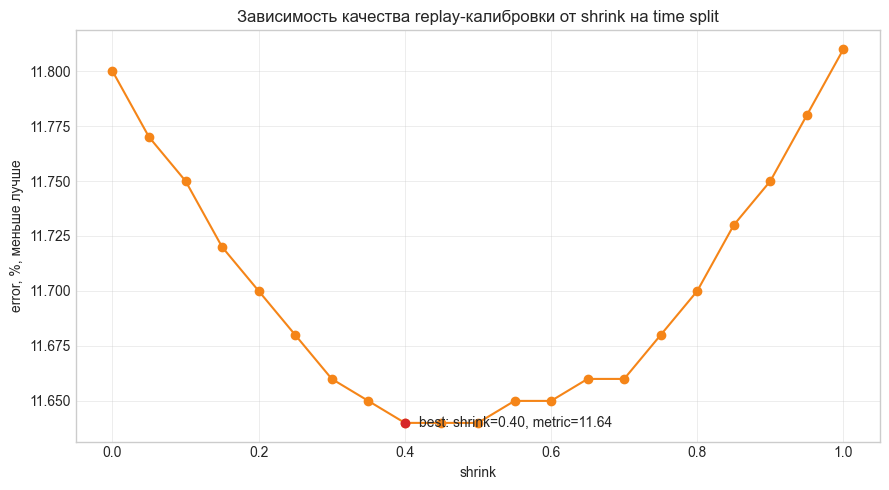

In [282]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(shrink_metric_table['shrink'], shrink_metric_table['metric'], marker='o', color='#F58518')
ax.scatter([best_shrink_row['shrink']], [best_shrink_row['metric']], color='#D62728', zorder=3)
ax.text(
    best_shrink_row['shrink'] + 0.02,
    best_shrink_row['metric'],
    f"best: shrink={best_shrink_row['shrink']:.2f}, metric={best_shrink_row['metric']:.2f}",
    va='center',
)
ax.set_title('Зависимость качества replay-калибровки от shrink на time split')
ax.set_xlabel('shrink')
ax.set_ylabel('error, %, меньше лучше')
plt.tight_layout()

shrink_metric_table.round(3)

## 7. Изменение ошибки по каждому таргету

In [283]:
def per_target_metric(pred: pd.DataFrame) -> dict[str, float]:
    return {
        target: 100 * (np.exp(get_smoothed_log_mape_column_value(pred[target], answers[target], EPSILON)) - 1)
        for target in TARGET_COLUMNS
    }

target_rows = []
for name, filename, kind in prediction_sources:
    pred = read_prediction(filename)
    if pred is None:
        continue
    for target, metric in per_target_metric(pred).items():
        target_rows.append({'approach': name, 'target': target, 'metric': metric})

target_metric_table = pd.DataFrame(target_rows)
target_metric_table.pivot(index='approach', columns='target', values='metric').round(3)

target,at_least_one,at_least_three,at_least_two
approach,,,
replay_calibrated,14.363,8.701,10.556
shift_replay,15.002,8.731,10.802


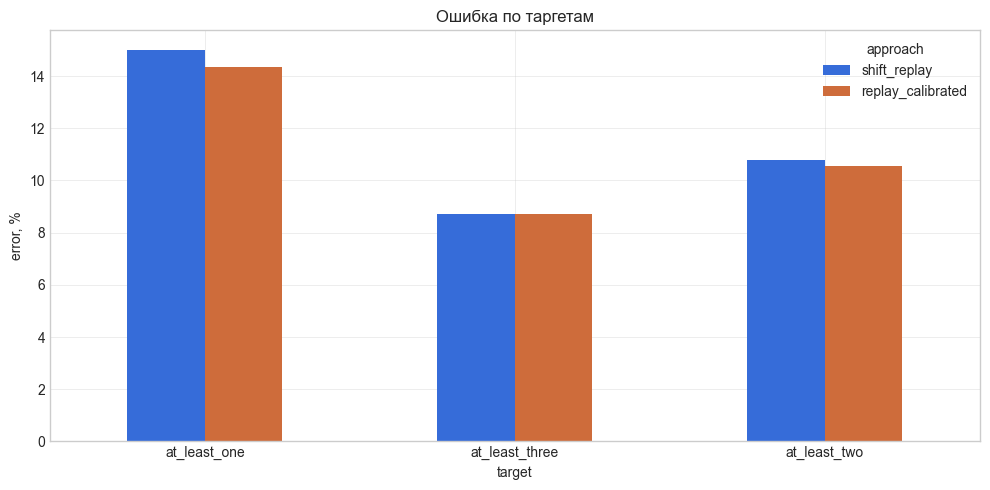

In [284]:
pivot = target_metric_table.pivot(index='target', columns='approach', values='metric')
selected = [c for c in ['shift_replay', 'replay_calibrated'] if c in pivot.columns]
pivot[selected].plot(kind='bar', figsize=(10, 5))
plt.title('Ошибка по таргетам')
plt.ylabel('error, %')
plt.xticks(rotation=0)
plt.tight_layout()


## 8. Что модель считает важным

Ниже обучается консервативный CatBoost для residual-калибровки. Важности признаков нужны не для финального скоринга, а для объяснения: какие группы признаков используются при поправке replay.

### 8.1 Feature importance обычного CatBoost

Ниже CatBoost обучается напрямую предсказывать `at_least_one/two/three` по обычным признакам `features_validate.tsv`, без replay-столбцов. Этот график объясняет, на какие факторы опирается обычная табличная ML-модель.


In [285]:
catboost_direct_model = MultiOutputRegressor(CatBoostRegressor(
    iterations=500,
    learning_rate=0.03,
    depth=5,
    l2_leaf_reg=5.0,
    loss_function='RMSE',
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
))
catboost_direct_model.fit(features, transform_target(answers))

catboost_direct_importance = np.vstack([
    estimator.feature_importances_
    for estimator in catboost_direct_model.estimators_
]).mean(axis=0)

catboost_direct_importance_df = (
    pd.DataFrame({
        'feature': features.columns,
        'importance': catboost_direct_importance,
    })
    .assign(group=lambda df: df['feature'].map(feature_group))
    .sort_values('importance', ascending=False)
)
catboost_direct_importance_df.head(20)

,feature,importance,group
4,window_length,29.692244,time_window
5,log_window_length,27.520166,time_window
92,recent_31d_intersection_sessions_per_user,13.268743,recent_intersection
78,recent_31d_audience_win_rate,3.864269,recent_audience
90,recent_31d_intersection_active_user_share,3.558850,recent_intersection
94,recent_31d_intersection_win_rate,2.620858,recent_intersection
91,recent_31d_intersection_sessions,2.164636,recent_intersection
88,recent_31d_intersection_log_impressions,2.071247,recent_intersection
87,recent_31d_intersection_impressions,1.958029,recent_intersection
0,cpm,1.129342,cpm


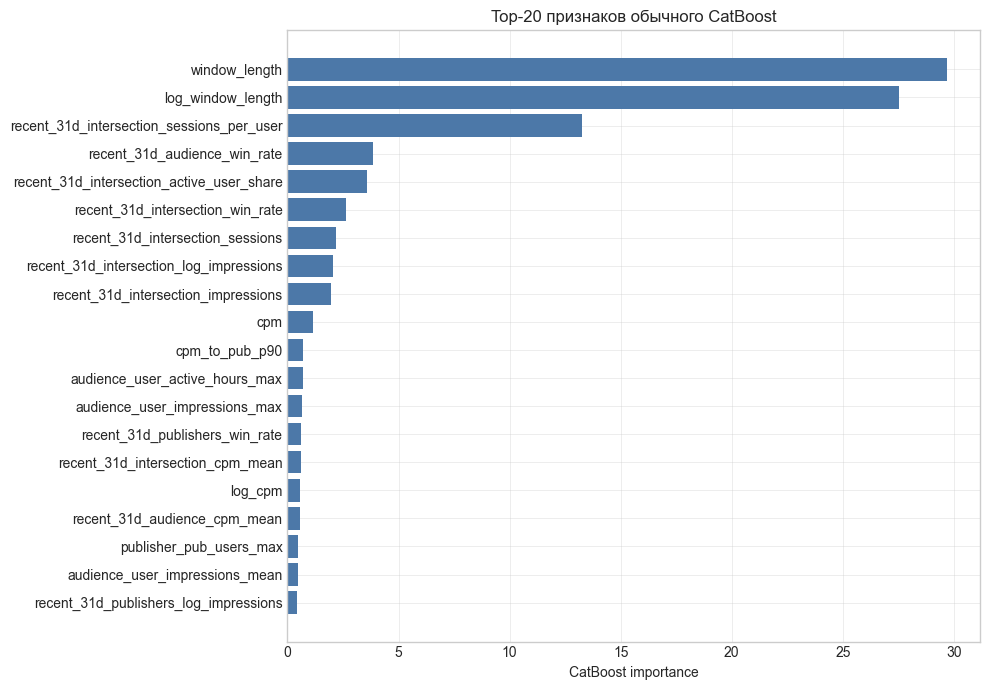

In [286]:
top_direct = catboost_direct_importance_df.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_direct['feature'], top_direct['importance'], color='#4C78A8')
ax.set_title('Top-20 признаков обычного CatBoost')
ax.set_xlabel('CatBoost importance')
plt.tight_layout()

,group,importance
7,time_window,57.855553
5,recent_intersection,26.280481
4,recent_audience,5.212325
0,audience_aggregates,4.410531
2,cpm,2.667368
6,recent_publishers,2.022015
3,publisher_aggregates,1.463778
1,campaign,0.087950


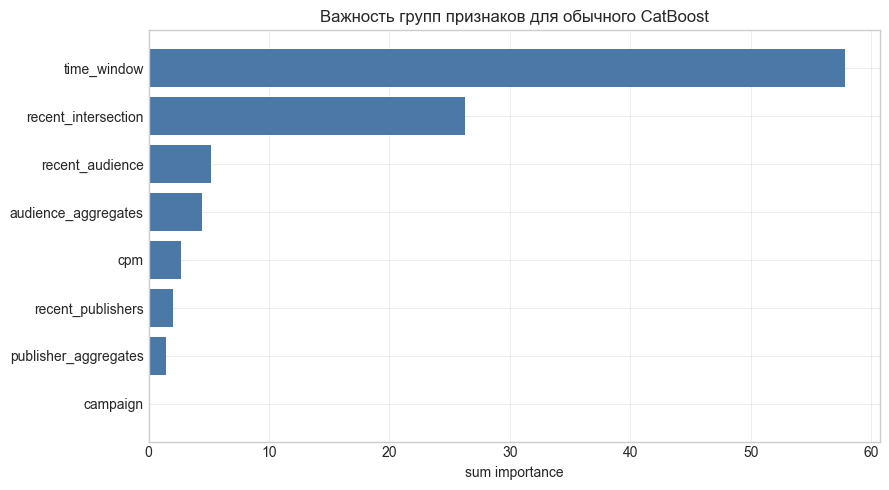

In [287]:
direct_group_importance = (
    catboost_direct_importance_df
    .groupby('group', as_index=False)['importance']
    .sum()
    .sort_values('importance')
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(direct_group_importance['group'], direct_group_importance['importance'], color='#4C78A8')
ax.set_title('Важность групп признаков для обычного CatBoost')
ax.set_xlabel('sum importance')
plt.tight_layout()

direct_group_importance.sort_values('importance', ascending=False)

In [288]:
base_prediction = shift_replay.rename(columns={
    'shift_replay_at_least_one': 'at_least_one',
    'shift_replay_at_least_two': 'at_least_two',
    'shift_replay_at_least_three': 'at_least_three',
})[TARGET_COLUMNS]

residual_target = transform_target(answers) - transform_target(base_prediction)

importance_model = MultiOutputRegressor(CatBoostRegressor(
    iterations=350,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=10.0,
    loss_function='RMSE',
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
))
importance_model.fit(features_full, residual_target)

importance = np.vstack([est.feature_importances_ for est in importance_model.estimators_]).mean(axis=0)
importance_df = (
    pd.DataFrame({'feature': features_full.columns, 'importance': importance})
    .assign(group=lambda df: df['feature'].map(feature_group))
    .sort_values('importance', ascending=False)
)
importance_df.head(25)

,feature,importance,group
99,shift_replay_at_least_three,8.473841,shift_replay
98,shift_replay_at_least_two,7.826553,shift_replay
97,shift_replay_at_least_one,5.736847,shift_replay
78,recent_31d_audience_win_rate,4.498312,recent_audience
94,recent_31d_intersection_win_rate,3.579770,recent_intersection
3,hour_end,3.115810,time_window
5,log_window_length,2.846351,time_window
7,end_hour_of_day,2.016990,time_window
2,hour_start,2.016824,time_window
19,audience_city_id_max,1.985804,audience_aggregates


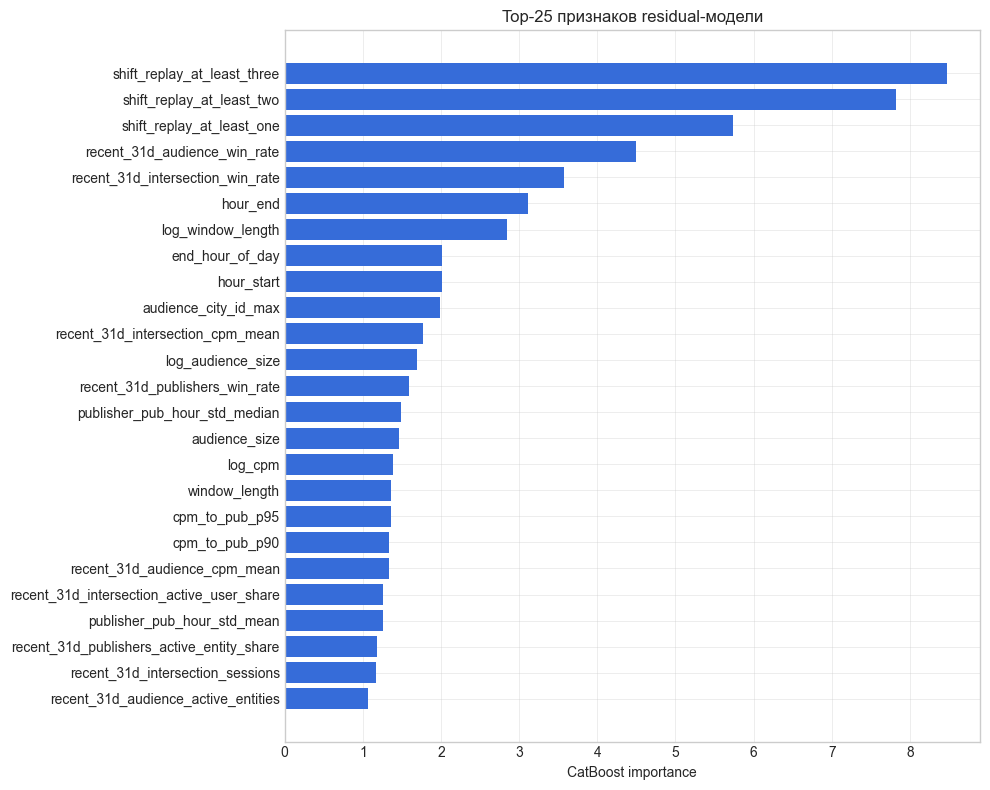

In [289]:
top = importance_df.head(25).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top['feature'], top['importance'])
ax.set_title('Top-25 признаков residual-модели')
ax.set_xlabel('CatBoost importance')
plt.tight_layout()

,group,importance
7,shift_replay,22.037240
0,audience_aggregates,18.293497
3,publisher_aggregates,14.163922
8,time_window,12.002229
5,recent_intersection,10.821329
4,recent_audience,10.393256
6,recent_publishers,6.114359
2,cpm,4.481770
1,campaign,1.692399


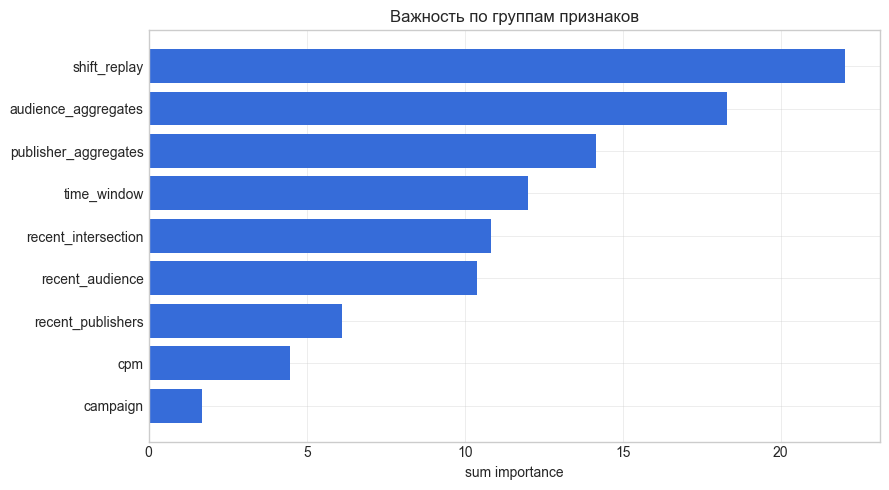

In [290]:
group_importance = importance_df.groupby('group', as_index=False)['importance'].sum().sort_values('importance')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(group_importance['group'], group_importance['importance'])
ax.set_title('Важность по группам признаков')
ax.set_xlabel('sum importance')
plt.tight_layout()
group_importance.sort_values('importance', ascending=False)

## 9. Actual vs predicted

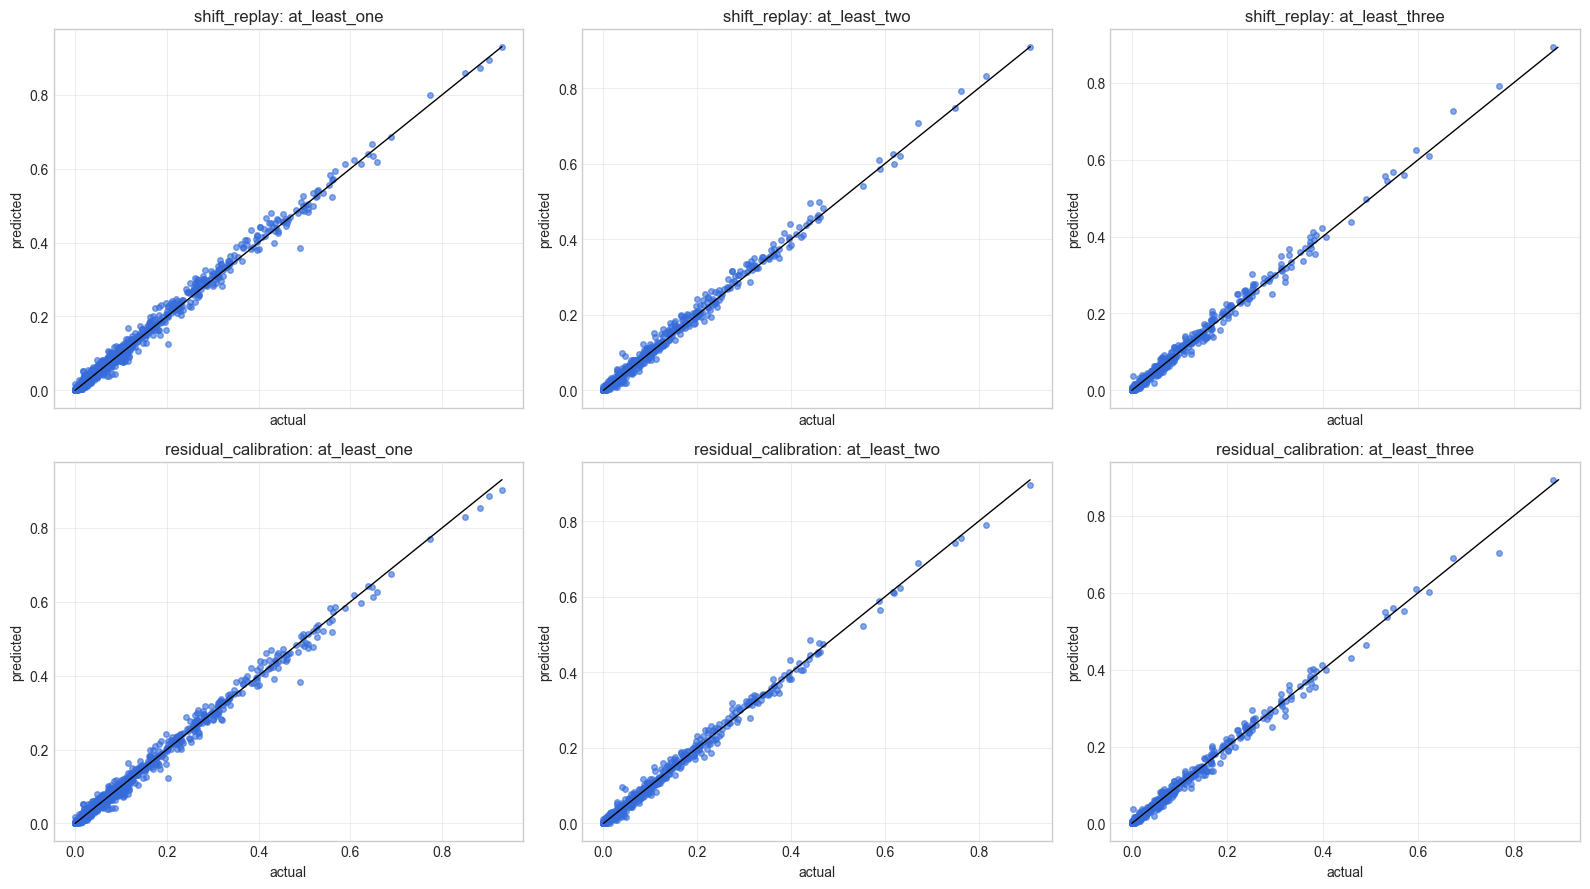

In [291]:
calibrated = read_prediction('replay_calibrated_predictions.tsv')
shift = read_prediction('shift_replay_predictions.tsv')

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex='col', sharey='col')
for col_idx, target in enumerate(TARGET_COLUMNS):
    for row_idx, (title, pred) in enumerate([('shift_replay', shift), ('residual_calibration', calibrated)]):
        ax = axes[row_idx, col_idx]
        ax.scatter(answers[target], pred[target], s=16, alpha=0.6)
        limit = max(answers[target].max(), pred[target].max())
        ax.plot([0, limit], [0, limit], color='black', linewidth=1)
        ax.set_title(f'{title}: {target}')
        ax.set_xlabel('actual')
        ax.set_ylabel('predicted')

plt.tight_layout()

## 10. Итоговая схема решения

1. Восстанавливаем сессии пользователей по правилу разрыва в 6 часов.
2. Строим кампанийные признаки: параметры кампании, аудитория, площадки, свежая история, пересечения аудитории и площадок.
3. Считаем `shift_replay`: симулируем кампанию на предыдущем месяце с учетом правил аукциона.
4. Обучаем residual-модель: она предсказывает не сам ответ, а ошибку replay в лог-пространстве.
5. Ограничиваем силу поправки через `shrink`, чтобы не переобучиться на 1008 строках.

Главный результат: residual-калибровка улучшает replay-бейзлайн, сохраняя интерпретируемость решения и связь с механикой задачи.